# RadSplat threshold pruning + SplatFormer

Every run so far thins a predicted field down to a *number* of Gaussians: a
budget drawn per step, and a rule that ranks the field so the budget keeps a
prefix of the order. This experiment prunes the way RadSplat itself does,
by a **score threshold**: every Gaussian whose RadSplat score (the largest
blending weight it carries on any ray of the context views) falls under
`SCORE_THRESHOLD` is dropped, and the size of the field is whatever that
leaves. The refiner is then trained on those fields.

When what survives the threshold still does not fit the card
(`DEVICE_MAX_GAUSSIANS`), the survivors are subsampled down to it, either
uniformly or with a draw proportional to their score
(`OVERFLOW_SELECTION`).

The notebook has three parts:

1. **Training** — the recipe of `configs/train.yaml` with the threshold in
   place of the budget, validated every `VALIDATION_INTERVAL` steps on the
   validation split.
2. **Test-set evaluation** — the DL3DV test split, on the windows and
   context view counts of `configs/eval.yaml`, scoring the whole field, the
   thresholded field ("basic RadSplat") and the thresholded field through
   the trained refiner.
3. **Figures** — PSNR, number of kept primitives and number of scenes per
   context view count for each of the three.

Parts 2 and 3 can be run on their own once a checkpoint exists.


In [1]:
import gc
import json
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import sys
from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# The repository root, whether the notebook is opened from notebooks/ or from the root
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    assert ROOT.parent != ROOT, "Open this notebook from inside the anyprune repository"
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import torch
import wandb
from matplotlib.ticker import MaxNLocator
from tabulate import tabulate
from torch import Generator, Tensor
from tqdm.auto import tqdm

from anyprune.datasets import DL3DVDataset, split_scenes
from anyprune.evaluation import psnr
from anyprune.gaussians import BlendingWeights, Gaussians, blending_weights, radsplat_score
from anyprune.models import SplatFormer, build_reconstructor
from anyprune.models.utils import build_splatformer_optimizer, build_splatformer_scheduler
from anyprune.training import (
    PhotometricLoss, Reconstruction, ViewSet, plan_context_views, reconstruct,
    sample_num_context_views, sample_view_indices,
)
from anyprune.utils import load_dotenv, out_of_memory, set_rng_seed
from anyprune.viz import REFERENCE_COLOR, SERIES_COLORS
# The pieces of the training loop that do not depend on the budget
from train import ScenePrefetcher, recover_from_oom


## Hyperparameters

Copied as constants from `configs/base.yaml`, `configs/train.yaml` and
`configs/machine/desktop.yaml`, with the recipe the protocol refiners were
trained with (`pruning.max_scoring_views=8`, validation on the training
reconstructor only). The only settings *not* carried over are
`budget.*` — the fraction band and the histogram balancing — because the
threshold replaces the budget: a step keeps what scores above it, and no
count is drawn.


In [ ]:
# --- configs/base.yaml ---
SEED = 42
SPLITS = {"train": 0.8, "val": 0.1, "test": 0.1}
SPLIT_SEED = 0
COMPENSATION_EXPONENT = 1.0
ANYSPLAT_CHECKPOINT = "lhjiang/anysplat"
YONOSPLAT_CHECKPOINT = "botaoye/YoNoSplat/dl3dv_224x224_ctx2to32.ckpt"

# --- configs/machine/desktop.yaml ---
CHECKPOINTS_DIR = ROOT / "checkpoints"
OUTPUTS_DIR = ROOT / "outputs"
DL3DV_ROOT_DIR = Path("/home/nicola/Desktop/Anysplat-improved/datasets/dl3dv")
DL3DV_IMAGES_SUBDIR = "images_8"
# Loose ceiling on the amount of Gaussians the GPU can hold at training time
DEVICE_MAX_GAUSSIANS = 500_000
DEVICE_MAX_VIEWS_PER_RENDER = 2
DEVICE_MAX_INTERSECTIONS = 100_000_000

# --- configs/train.yaml ---
# The context view counts a step reconstructs from, one drawn uniformly per step
CONTEXT_VIEWS = [2, 4, 8, 16, 24, 32, 64]
VIEW_STRIDE = 1
CONTEXT_DOWNSCALE = 1
SUPERVISION_VIEWS = "all"       # context | test | all
SUPERVISION_MAX_VIEWS = 8
TRAINING_RECONSTRUCTOR = "YoNoSplat"
SPLATFORMER_CHECKPOINT = CHECKPOINTS_DIR / "splatformer" / "train-on-objaverse.pth"
ZERO_OUTPUT_HEADS = False
GRADIENT_CHECKPOINTING = True
TOTAL_STEPS = 200
LEARNING_RATES = {
    "base": 3e-5, "embedding": 3e-5, "backbone": 3e-5, "features_dc": 3e-5,
    "features_rest": 1.5e-6, "scales": 3e-5, "opacities": 3e-5, "quats": 3e-5,
    "means": 3e-5,
}
LR_SCHEDULE = "constant"
GRAD_CLIP_NORM = 2.0
L1_LOSS_WEIGHT = 1.0
L2_LOSS_WEIGHT = 0.0
LPIPS_LOSS_WEIGHT = 0.0
ENABLE_AMP = True
OOM_RETRY_FACTOR = 0.6
OOM_MAX_RETRIES = 3
PRUNING_BATCHES_PER_PASS = 32
# At most how many of the context views the score is measured over during
# training, drawn evenly along the capture (the protocol refiners' setting;
# the test-set evaluation below measures over every context view)
MAX_SCORING_VIEWS = 8
VALIDATION_INTERVAL = 500
VALIDATION_NUM_SCENES = 16
VALIDATION_CONTEXT_VIEWS = [6]
VALIDATION_SCORED_VIEWS = 6
VALIDATION_SKIP_INITIAL = False
LOG_INTERVAL = 10
WANDB_PROJECT = "anyprune"
WANDB_MODE = "online"           # online | offline | disabled
DETERMINISTIC = False

# --- New in this experiment ---
# A Gaussian whose RadSplat score (peak blending weight over the context
# views) is under this is dropped. RadSplat's own default; 0.25 is its
# aggressive setting.
SCORE_THRESHOLD = 0.01
# When more than DEVICE_MAX_GAUSSIANS survive the threshold, how the step
# picks which of them it keeps: 'uniform' draws at random among them,
# 'weighted' draws without replacement with probability proportional to
# score ** (1 / OVERFLOW_TEMPERATURE)
OVERFLOW_SELECTION = "uniform"  # uniform | weighted
OVERFLOW_TEMPERATURE = 1.0
# Opacity compensation (base.yaml: enabled) raises the opacities of a
# field thinned to a share f of itself to 1 - (1 - a)^(exponent / f).
# Off here so that the refiner is trained, and evaluated, on the very
# field basic RadSplat leaves; a smoke run showed the threshold does take
# optical depth out (26.2 -> 21.9 dB at 6 views, 38% kept), so it is a
# switch worth flipping in a second run
COMPENSATION_ENABLED = False
# The refiner's BatchNorm reads each field's own statistics rather than the
# running averages of training, at validation and at evaluation alike (see
# refiner.batch_statistics in configs/eval.yaml)
REFINER_BATCH_STATISTICS = True

# A field the threshold leaves fewer Gaussians than this is not refined:
# the step (or validation scene) is skipped and counted. PTv3 sizes its
# serialization cube from the spread of the points and a field of one
# Gaussian, or a few sharing a grid cell, gives it a cube of depth 0
MIN_GAUSSIANS = 16

RUN_NAME = f"radsplat-t{SCORE_THRESHOLD:g}-{OVERFLOW_SELECTION}-s{SEED}"
RUN_DIR = OUTPUTS_DIR / "train" / RUN_NAME
REFINER_CHECKPOINT = RUN_DIR / "checkpoints" / "model_final.pth"

# --- Test-set evaluation (configs/eval.yaml) ---
# Every scene is a window of 2 * max(EVAL_CONTEXT_VIEWS) contiguous frames,
# alternating context and test frames; a view count k uses the first 2k
EVAL_CONTEXT_VIEWS = [3, 6, 16, 32, 48, 64]
EVAL_GENERATORS = ["YoNoSplat"]
EVAL_NUM_SCENES = None          # None for the whole test split
EVAL_OUTPUT_DIR = OUTPUTS_DIR / "eval-threshold"

assert OVERFLOW_SELECTION in ("uniform", "weighted"), OVERFLOW_SELECTION
assert 0.0 < SCORE_THRESHOLD < 1.0, SCORE_THRESHOLD
assert OVERFLOW_TEMPERATURE > 0.0, OVERFLOW_TEMPERATURE
assert MIN_GAUSSIANS >= 2, MIN_GAUSSIANS


## The threshold rule

`blending_weights()` sweeps the field from the views it is measured over
and gives every Gaussian its peak blending weight, which is RadSplat's
score. The rule keeps what scores at least `SCORE_THRESHOLD`, and when
that is more than the card holds, subsamples the survivors down to it.


In [3]:
class FieldTooSparse(RuntimeError):
    """Fewer than MIN_GAUSSIANS survived the threshold."""

    def __init__(self, num_above: int, num_predicted: int):
        super().__init__(f"{num_above} of {num_predicted:,} Gaussians reach the threshold")
        self.num_above = num_above
        self.num_predicted = num_predicted


@dataclass(frozen=True)
class ThresholdPruner:
    """
    RadSplat's pruning as the paper writes it: drop every Gaussian whose
    score is under 'threshold'. With 'max_gaussians' the survivors are
    then subsampled down to that many, uniformly or in proportion to
    their score.
    """
    threshold: float
    overflow_selection: str = "uniform"
    overflow_temperature: float = 1.0

    @torch.no_grad()
    def keep(
        self,
        gaussians: Gaussians,
        measured: BlendingWeights,
        max_gaussians: Optional[int] = None,
        generator: Optional[Generator] = None,
    ) -> Tuple[Gaussians, int]:
        """
        The Gaussians the rule keeps and how many survived the threshold
        before any subsampling, so that a caller can tell a field the
        threshold sized from one the cap did.

        'generator' is a CPU one, the way the rest of the project seeds its
        draws.
        """
        score = radsplat_score(measured)
        above = torch.nonzero(score >= self.threshold).squeeze(1)
        if above.numel() == 0:
            # A field nothing in which reaches the threshold: keep the one
            # Gaussian that came closest rather than an empty field
            above = score.argmax().reshape(1)
        num_above = above.numel()

        if max_gaussians is not None and num_above > max_gaussians:
            if self.overflow_selection == "uniform":
                order = torch.randperm(num_above, generator=generator).to(above.device)
            else:
                # Drawing without replacement in proportion to the score,
                # all at once: a Gumbel perturbation of the log score,
                # sorted, is the same draw as taking one Gaussian at a
                # time and renormalizing what is left (see Pruner.order)
                noise = torch.rand(num_above, generator=generator).to(score.device)
                noise = noise.clamp(min=torch.finfo(score.dtype).tiny)
                keys = score[above].log() / self.overflow_temperature - (-noise.log()).log()
                order = torch.argsort(keys, descending=True)
            above = above[order[:max_gaussians]]
        return gaussians[above], num_above


def scoring_views(context: ViewSet) -> ViewSet:
    """
    The context views a score is measured over during training: all of
    them, or at most MAX_SCORING_VIEWS drawn evenly along the capture.
    """
    if MAX_SCORING_VIEWS is None or len(context) <= MAX_SCORING_VIEWS:
        return context
    return context[torch.linspace(0, len(context) - 1, MAX_SCORING_VIEWS).round().long()]


def thin(
    pruner: ThresholdPruner,
    field: Gaussians,
    views: ViewSet,
    max_gaussians: Optional[int],
    generator: Optional[Generator] = None,
) -> Tuple[Gaussians, int]:
    """
    Measure a field over 'views', threshold it and cap it, returning the
    kept Gaussians (compensated against the share of the field they are,
    when COMPENSATION_ENABLED) and how many survived the threshold. Raises
    FieldTooSparse when fewer than MIN_GAUSSIANS did.
    """
    measured = blending_weights(
        field, views.poses, views.intrinsics, views.image_shape,
        batches_per_pass=PRUNING_BATCHES_PER_PASS,
        max_intersections=DEVICE_MAX_INTERSECTIONS,
    )
    kept, num_above = pruner.keep(field, measured, max_gaussians, generator)
    del measured
    if num_above < MIN_GAUSSIANS:
        raise FieldTooSparse(num_above, field.num_gaussians)
    if COMPENSATION_ENABLED:
        kept = kept.compensate(kept.num_gaussians / field.num_gaussians, exponent=COMPENSATION_EXPONENT)
    return kept, num_above


def refine(splatformer: SplatFormer, gaussians: Gaussians, enable_amp: Optional[bool] = None) -> Gaussians:
    """Run SplatFormer over a set of Gaussians, in half precision if asked."""
    with torch.cuda.amp.autocast(enabled=ENABLE_AMP if enable_amp is None else enable_amp):
        return splatformer(gaussians)


def render_psnr(gaussians: Gaussians, views: ViewSet) -> float:
    rendered, _ = gaussians.rasterize(
        views.poses, views.intrinsics, views.image_shape,
        views_per_pass=DEVICE_MAX_VIEWS_PER_RENDER,
        max_intersections=DEVICE_MAX_INTERSECTIONS,
    )
    return psnr(rendered, views.images).mean().item()


pruner = ThresholdPruner(SCORE_THRESHOLD, OVERFLOW_SELECTION, OVERFLOW_TEMPERATURE)


## Part 1: training

A step samples a scene and a context view count, reconstructs with the
frozen reconstructor, thresholds the prediction over at most
`MAX_SCORING_VIEWS` of the context views, caps it at what the card holds,
refines with SplatFormer and takes the photometric loss on at most
`SUPERVISION_MAX_VIEWS` of the views. A step that runs out of memory is
retried with the cap lowered by `OOM_RETRY_FACTOR`.


In [4]:
def training_step(
    splatformer, reconstructor, criterion, optimizer, scaler,
    scene: Dict[str, Tensor], context_idx: Tensor, test_idx: Tensor,
    generator: Generator, budget_scale: float = 1.0,
):
    """
    Reconstruct, threshold, refine, score and take one optimizer step,
    returning what the logging needs. Raises on a card that ran out of
    memory; 'budget_scale' lowers the cap on a retry.
    """
    reconstruction = reconstruct(
        reconstructor, scene, context_idx, test_idx,
        generator=generator, context_downscale=CONTEXT_DOWNSCALE,
    )
    predicted = reconstruction.gaussians.num_gaussians
    cap = max(round(DEVICE_MAX_GAUSSIANS * budget_scale), 1)
    reconstruction.gaussians, num_above = thin(
        pruner, reconstruction.gaussians, scoring_views(reconstruction.context),
        cap, generator,
    )
    views = reconstruction.views(SUPERVISION_VIEWS).thin(SUPERVISION_MAX_VIEWS, generator=generator)

    refined = refine(splatformer, reconstruction.gaussians)
    rendered, _ = refined.rasterize(
        views.poses, views.intrinsics, views.image_shape,
        views_per_pass=DEVICE_MAX_VIEWS_PER_RENDER,
    )
    loss, terms = criterion(rendered, views.images)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    if GRAD_CLIP_NORM > 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(splatformer.parameters(), GRAD_CLIP_NORM)
    scaler.step(optimizer)
    scaler.update()
    return reconstruction, views, rendered.detach(), loss.item(), terms, predicted, num_above


@torch.no_grad()
def validate(splatformer, reconstructor, dataset, scene_indices, num_context_views: int) -> Dict[str, float]:
    """
    Threshold every validation scene reconstructed from 'num_context_views'
    views and score the whole field, the thresholded one and the refined
    one on its held-out views, returning the means over the scenes that fit
    and how many that was. The views and the draws come off a generator
    seeded by the scene alone, so that every pass scores the same thing.
    """
    was_training = splatformer.training
    splatformer.eval()
    device = next(splatformer.parameters()).device
    scores = defaultdict(list)
    for scene_idx in tqdm(scene_indices, desc="Validating", unit="scene", leave=False):
        generator = Generator().manual_seed(SPLIT_SEED + scene_idx)
        frames, context_idx, test_idx = plan_context_views(
            dataset.num_frames(scene_idx), num_context_views, stride=VIEW_STRIDE, generator=generator,
        )
        scene = {name: value.to(device) for name, value in dataset.get_frames(scene_idx, frames).items()}
        reconstruction = thinned = refined = None
        try:
            reconstruction = reconstruct(
                reconstructor, scene, context_idx, test_idx,
                generator=generator, context_downscale=CONTEXT_DOWNSCALE,
            )
            reconstruction.test = reconstruction.test.thin(
                VALIDATION_SCORED_VIEWS, generator=Generator().manual_seed(SPLIT_SEED + scene_idx)
            )
            reconstruction.context = reconstruction.context.thin(
                VALIDATION_SCORED_VIEWS, generator=Generator().manual_seed(SPLIT_SEED + scene_idx)
            )
            field, views = reconstruction.gaussians, reconstruction.test
            thinned, num_above = thin(
                pruner, field, scoring_views(reconstruction.context), None,
                Generator().manual_seed(SPLIT_SEED + scene_idx),
            )
            # In single precision: spconv has no half-precision kernel out of training mode
            refined = refine(splatformer, thinned, enable_amp=False)
            measured = {
                "psnr_full": render_psnr(field, views),
                "psnr_input": render_psnr(thinned, views),
                "psnr_refined": render_psnr(refined, views),
                "predicted_gaussians": field.num_gaussians,
                "num_gaussians": thinned.num_gaussians,
                "kept_fraction": thinned.num_gaussians / field.num_gaussians,
            }
        except FieldTooSparse as error:
            tqdm.write(f"  scene {scene_idx} too sparse ({error}), skipped")
            continue
        except RuntimeError as error:
            if not out_of_memory(error):
                raise
            error.__traceback__ = None
            tqdm.write(f"  scene {scene_idx} did not fit, skipped")
            continue
        finally:
            del scene, reconstruction, thinned, refined
            torch.cuda.empty_cache()
        for name, value in measured.items():
            scores[name].append(value)
    splatformer.train(was_training)
    num_scenes = len(scores["psnr_input"])
    metrics = {name: sum(values) / len(values) for name, values in scores.items()}
    metrics["psnr_gain"] = metrics["psnr_refined"] - metrics["psnr_input"]
    metrics["psnr_vs_full"] = metrics["psnr_refined"] - metrics["psnr_full"]
    metrics["num_scenes"] = num_scenes
    return metrics


def run_validation(splatformer, reconstructor, dataset, scene_indices, step: int):
    """Validate at every count of VALIDATION_CONTEXT_VIEWS and log under val/."""
    splatformer.zero_grad(set_to_none=True)
    torch.cuda.empty_cache()
    logged = {}
    for num_context_views in VALIDATION_CONTEXT_VIEWS:
        metrics = validate(splatformer, reconstructor, dataset, scene_indices, num_context_views)
        fit = "" if metrics["num_scenes"] == len(scene_indices) else f" (over the {metrics['num_scenes']} scenes that fit)"
        tqdm.write(
            f"  [val] {TRAINING_RECONSTRUCTOR} from {num_context_views} views, threshold {SCORE_THRESHOLD:g} "
            f"keeps {metrics['num_gaussians']:,.0f} of {metrics['predicted_gaussians']:,.0f} Gaussians "
            f"({metrics['kept_fraction']:.1%}): {metrics['psnr_full']:.2f} dB whole, "
            f"{metrics['psnr_input']:.2f} dB thresholded, {metrics['psnr_refined']:.2f} dB refined "
            f"({metrics['psnr_gain']:+.2f}), {metrics['psnr_vs_full']:+.2f} dB against whole{fit}"
        )
        logged.update({
            f"val/{TRAINING_RECONSTRUCTOR}/{num_context_views}v/{name}": value
            for name, value in metrics.items()
        })
    wandb.log(logged, step=step)
    torch.cuda.empty_cache()


In [5]:
load_dotenv()
set_rng_seed(SEED, deterministic=DETERMINISTIC)
torch.set_float32_matmul_precision("high")
device = torch.device("cuda")

loading = tqdm(total=3, desc="Loading", unit="stage")
loading.set_postfix_str("DL3DV")
dataset = DL3DVDataset(str(DL3DV_ROOT_DIR), DL3DV_IMAGES_SUBDIR)
splits = split_scenes(len(dataset), SPLITS, SPLIT_SEED)
validation_scenes = splits["val"][:VALIDATION_NUM_SCENES]
loading.update()
tqdm.write(
    f"DL3DV initialized with {len(dataset)} scenes: "
    + ", ".join(f"{len(scenes)} {name}" for name, scenes in splits.items())
    + f", validating on {len(validation_scenes)} of them."
)

loading.set_postfix_str(f"frozen {TRAINING_RECONSTRUCTOR}")
reconstructor = build_reconstructor(TRAINING_RECONSTRUCTOR, ANYSPLAT_CHECKPOINT, YONOSPLAT_CHECKPOINT).to(device)
loading.update()
loading.set_postfix_str("SplatFormer")
splatformer = SplatFormer(
    str(SPLATFORMER_CHECKPOINT), quiet=True,
    zero_output_heads=ZERO_OUTPUT_HEADS,
    gradient_checkpointing=GRADIENT_CHECKPOINTING,
    batch_statistics=REFINER_BATCH_STATISTICS,
).to(device)
splatformer.train()
loading.update()
loading.close()
print(f"SplatFormer has {sum(p.numel() for p in splatformer.parameters() if p.requires_grad) / 1e6:.1f}M trainable parameters.")

criterion = PhotometricLoss(l1_weight=L1_LOSS_WEIGHT, l2_weight=L2_LOSS_WEIGHT, lpips_weight=LPIPS_LOSS_WEIGHT)
optimizer = build_splatformer_optimizer(splatformer.model, lr_dict=dict(LEARNING_RATES))
scheduler = build_splatformer_scheduler(optimizer, schedule=LR_SCHEDULE, total_step=TOTAL_STEPS)
scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP)

# Every constant above, as the run's config
hyperparameters = {
    name: (str(value) if isinstance(value, Path) else value)
    for name, value in dict(globals()).items()
    if name.isupper() and isinstance(value, (bool, int, float, str, list, dict, Path, type(None)))
}
run = wandb.init(
    project=WANDB_PROJECT, mode=WANDB_MODE, name=RUN_NAME, config=hyperparameters,
    notes=f"RadSplat score threshold {SCORE_THRESHOLD:g} in place of a budget, {OVERFLOW_SELECTION} subsampling over {DEVICE_MAX_GAUSSIANS:,}",
    settings=wandb.Settings(x_disable_stats=True),
)
checkpoint_dir = RUN_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
print(f"Writing checkpoints to {checkpoint_dir}")


Loading:   0%|          | 0/3 [00:00<?, ?stage/s]

DL3DV initialized with 541 scenes: 433 train, 54 val, 54 test, validating on 16 of them.


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


SplatFormer has 47.9M trainable parameters.


wandb: Currently logged in as: nicola-leonetti (nicola-leonetti-org) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Writing checkpoints to /home/nicola/Desktop/anyprune/outputs/train/radsplat-t0.25-uniform-s42/checkpoints


In [6]:
@dataclass
class StepPlan:
    """Everything one training step draws, before any of it is read."""
    scene_idx: int
    frames: Tensor
    context_idx: Tensor
    test_idx: Tensor


def draw_step(generator: Generator) -> StepPlan:
    """The scene a step trains on and the views it takes off it."""
    scenes = splits["train"]
    scene_idx = scenes[torch.randint(len(scenes), (1,), generator=generator).item()]
    num_context_views = sample_num_context_views(CONTEXT_VIEWS, generator=generator)
    frames, context_idx, test_idx = plan_context_views(
        dataset.num_frames(scene_idx), num_context_views, stride=VIEW_STRIDE, generator=generator,
    )
    return StepPlan(scene_idx, frames, context_idx, test_idx)


# Every step's randomness, the scene it draws and the views and Gaussians
# it samples, comes off this one generator
generator = Generator().manual_seed(SEED)
prefetcher = ScenePrefetcher(dataset, device)
prefetcher.submit(draw_step(generator))
oom_retries = 0
sparse_skips = 0

progress = tqdm(range(TOTAL_STEPS), desc="Training", unit="step")
for step in progress:
    if step % VALIDATION_INTERVAL == 0 and not (step == 0 and VALIDATION_SKIP_INITIAL):
        tqdm.write(f"Validating at step {step}...")
        run_validation(splatformer, reconstructor, dataset, validation_scenes, step)

    no_room = False
    try:
        plan, scene = prefetcher.take()
    except RuntimeError as error:
        if not out_of_memory(error):
            raise
        no_room = True
    if no_room:
        tqdm.write(f"Step {step}: no room to read a scene in, clearing")
        recover_from_oom(optimizer, scaler)
        plan, scene = prefetcher.take()
    if step + 1 < TOTAL_STEPS:
        prefetcher.submit(draw_step(generator))
    context_views = len(plan.context_idx)

    step_result = None
    budget_scale = 1.0
    too_sparse = None
    for attempt in range(OOM_MAX_RETRIES + 1):
        ran_out = False
        try:
            step_result = training_step(
                splatformer, reconstructor, criterion, optimizer, scaler,
                scene, plan.context_idx, plan.test_idx, generator, budget_scale=budget_scale,
            )
            break
        except FieldTooSparse as error:
            too_sparse = error
            break
        except RuntimeError as error:
            if not out_of_memory(error):
                raise
            ran_out = True
        # Recovered out here rather than in the handler, which would still
        # hold the frames of the failed step and with them its autograd graph
        if ran_out:
            recover_from_oom(optimizer, scaler)
            oom_retries += 1
            budget_scale *= OOM_RETRY_FACTOR
            if attempt < OOM_MAX_RETRIES:
                tqdm.write(
                    f"Step {step}: out of memory, retrying scene {plan.scene_idx} with the cap at "
                    f"{round(DEVICE_MAX_GAUSSIANS * budget_scale):,} ({attempt + 1}/{OOM_MAX_RETRIES})"
                )
    if too_sparse is not None:
        sparse_skips += 1
        tqdm.write(
            f"Step {step}: skipped, scene {plan.scene_idx} from {context_views} context views "
            f"is too sparse ({too_sparse})"
        )
        del scene
        continue
    if step_result is None:
        tqdm.write(f"Step {step}: skipped, scene {plan.scene_idx} did not fit")
        del scene
        continue
    reconstruction, views, rendered, loss, terms, predicted, num_above = step_result
    scheduler.step()

    if step % LOG_INTERVAL == 0:
        with torch.no_grad():
            baseline, _ = reconstruction.gaussians.rasterize(
                views.poses, views.intrinsics, views.image_shape, views_per_pass=DEVICE_MAX_VIEWS_PER_RENDER,
            )
        psnr_input = psnr(baseline, views.images).mean().item()
        psnr_refined = psnr(rendered, views.images).mean().item()
        kept = reconstruction.gaussians.num_gaussians
        metrics = {f"train/{name}": value for name, value in terms.items()}
        metrics.update({
            "train/loss": loss,
            "train/num_gaussians": kept,
            "train/predicted_gaussians": predicted,
            "train/above_threshold": num_above,
            "train/threshold_fraction": num_above / predicted,
            "train/kept_fraction": kept / predicted,
            "train/overflowed": int(kept < num_above),
            "train/context_views": context_views,
            "train/supervision_views": len(views),
            "train/oom_retries": oom_retries,
            "train/sparse_skips": sparse_skips,
            "train/memory_live_gib": torch.cuda.memory_allocated() / 2 ** 30,
            "train/memory_peak_gib": torch.cuda.max_memory_allocated() / 2 ** 30,
            "train/psnr_refined": psnr_refined,
            "train/psnr_gain": psnr_refined - psnr_input,
        })
        wandb.log(metrics, step=step)
        progress.set_postfix(loss=f"{loss:.4f}", psnr_gain=f"{psnr_refined - psnr_input:+.2f}")
        capped = "" if kept == num_above else f", capped from {num_above:,}"
        tqdm.write(
            f"Step {step}: loss {loss:.4f}, PSNR {psnr_input:.2f} -> {psnr_refined:.2f} dB over "
            f"{kept:,} Gaussians ({kept / predicted:.1%} of the {predicted:,} predicted{capped}) "
            f"from {context_views} context views, supervised on {len(views)}, "
            f"peak {torch.cuda.max_memory_allocated() / 2 ** 30:.1f} GiB"
        )
    del step_result, reconstruction, views, rendered, scene

progress.close()
prefetcher.close()
run_validation(splatformer, reconstructor, dataset, validation_scenes, TOTAL_STEPS)
torch.save(splatformer.model.state_dict(), REFINER_CHECKPOINT)
print(f"Wrote {REFINER_CHECKPOINT}")
wandb.finish()


Training:   0%|          | 0/200 [00:00<?, ?step/s]

Validating at step 0...


Validating:   0%|          | 0/16 [00:00<?, ?scene/s]

  [val] YoNoSplat from 6 views, threshold 0.25 keeps 76 of 301,056 Gaussians (0.0%): 26.53 dB whole, 4.32 dB thresholded, 4.41 dB refined (+0.09), -22.11 dB against whole
Step 0: loss 0.6092, PSNR 3.75 -> 3.76 dB over 27 Gaussians (0.0% of the 401,408 predicted) from 8 context views, supervised on 8, peak 9.4 GiB
Step 1: skipped, scene 438 from 24 context views is too sparse (14 of 1,204,224 Gaussians reach the threshold)
Step 6: skipped, scene 469 from 8 context views is too sparse (14 of 401,408 Gaussians reach the threshold)
Step 10: loss 0.4018, PSNR 5.21 -> 6.55 dB over 25 Gaussians (0.0% of the 1,204,224 predicted) from 24 context views, supervised on 8, peak 9.4 GiB
Step 13: skipped, scene 240 from 32 context views is too sparse (9 of 1,605,632 Gaussians reach the threshold)
Step 20: loss 0.3419, PSNR 4.59 -> 7.38 dB over 26 Gaussians (0.0% of the 802,816 predicted) from 16 context views, supervised on 8, peak 9.6 GiB
Step 25: skipped, scene 261 from 64 context views is too spar

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x71f3f03093f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 71f412ac36a0, execution_count=6 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 71f412ac2f50, raw_cell="@dataclass
class StepPlan:
    """Everything one t.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bmy-desktop/home/nicola/Desktop/anyprune/notebooks/radsplat_threshold.ipynb#X45sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## Part 2: test-set evaluation

The protocol of `scripts/eval.py`: every test scene is a window of
`2 * max(EVAL_CONTEXT_VIEWS)` contiguous frames, alternating context and
test frames. At each view count the generator predicts a field from the
first frames of the window, and three things are scored on the context
views (self-reconstruction) and on the test views between them (novel
view synthesis):

- **full field** — the whole prediction;
- **RadSplat** — the field thresholded at `SCORE_THRESHOLD`, measured over
  every context view, no cap;
- **RadSplat + SplatFormer** — the same field through the refiner trained
  above.

Nothing is capped here: a field the refiner cannot hold is a scene missing
from that method's mean, which is what the "number of scenes" panel
counts. The training objects are released first so that the refiner is
loaded fresh from `REFINER_CHECKPOINT`, which is also what lets this part
run on its own.


In [ ]:
for name in ("splatformer", "optimizer", "scaler", "scheduler", "prefetcher", "reconstructor"):
    globals().pop(name, None)
gc.collect()
torch.cuda.empty_cache()

load_dotenv()
set_rng_seed(SEED, deterministic=DETERMINISTIC)
torch.set_float32_matmul_precision("high")
device = torch.device("cuda")
assert REFINER_CHECKPOINT.exists(), f"No refiner at {REFINER_CHECKPOINT}: train it above or point REFINER_CHECKPOINT at one"
loading = tqdm(total=2, desc="Loading", unit="stage")
loading.set_postfix_str("DL3DV")
dataset = DL3DVDataset(str(DL3DV_ROOT_DIR), DL3DV_IMAGES_SUBDIR)
test_scenes = split_scenes(len(dataset), SPLITS, SPLIT_SEED)["test"]
if EVAL_NUM_SCENES is not None:
    test_scenes = test_scenes[:EVAL_NUM_SCENES]
loading.update()
loading.set_postfix_str(f"refiner {REFINER_CHECKPOINT.name}")
refiner = SplatFormer(str(REFINER_CHECKPOINT), quiet=True, batch_statistics=REFINER_BATCH_STATISTICS).to(device).eval()
loading.update()
loading.close()

METHOD_FULL = "full field"
METHOD_RADSPLAT = f"RadSplat t={SCORE_THRESHOLD:g}"
METHOD_REFINED = f"RadSplat t={SCORE_THRESHOLD:g} + SplatFormer"
METHODS = [METHOD_FULL, METHOD_RADSPLAT, METHOD_REFINED]
BLOCKS = (("self", "context"), ("nvs", "test"))


def score(gaussians: Gaussians, reconstruction: Reconstruction) -> Dict[str, float]:
    """Mean PSNR of a field on each half of the scene."""
    return {f"{block}_psnr": render_psnr(gaussians, getattr(reconstruction, half)) for block, half in BLOCKS}


@torch.no_grad()
def evaluate_scene(reconstructor, scene, context_idx, test_idx, seed: int) -> List[dict]:
    """
    The three methods on one scene at one view count. The whole field and
    the thresholded one stand or fall together; the refined one has a
    guard of its own, so that a field too wide for the refiner still
    counts for the other two.
    """
    reconstruction = reconstruct(reconstructor, scene, context_idx, test_idx)
    field, context = reconstruction.gaussians, reconstruction.context
    predicted = field.num_gaussians
    thinned, num_above = thin(pruner, field, context, None, Generator().manual_seed(seed))
    records = [
        {"method": METHOD_FULL, "num_gaussians": predicted, **score(field, reconstruction)},
        {"method": METHOD_RADSPLAT, "num_gaussians": thinned.num_gaussians, **score(thinned, reconstruction)},
    ]
    del field
    try:
        # spconv has no half-precision kernels out of training mode
        with torch.cuda.amp.autocast(enabled=False):
            refined = refiner(thinned)
        records.append({"method": METHOD_REFINED, "num_gaussians": refined.num_gaussians, **score(refined, reconstruction)})
        del refined
    except RuntimeError as error:
        if not out_of_memory(error):
            raise
        error.__traceback__ = None
        torch.cuda.empty_cache()
        tqdm.write(f"  {thinned.num_gaussians:,} Gaussians did not fit through the refiner, skipped")
    return [{"context_views": len(context_idx), "predicted_gaussians": predicted, **record} for record in records]


AVERAGED = ("num_gaussians", "predicted_gaussians", "self_psnr", "nvs_psnr")


def summarize(records: List[dict]) -> List[dict]:
    """The mean over the scenes of every (generator, view count, method) cell."""
    groups = defaultdict(list)
    for record in records:
        groups[(record["generator"], record["context_views"], record["method"])].append(record)
    return [
        {
            "generator": generator, "context_views": views, "method": method, "num_scenes": len(group),
            **{key: sum(r[key] for r in group) / len(group) for key in AVERAGED},
        }
        for (generator, views, method), group in groups.items()
    ]


output_dir = EVAL_OUTPUT_DIR / datetime.now().strftime("%Y%m%d-%H%M%S")
output_dir.mkdir(parents=True, exist_ok=True)
window = 2 * max(EVAL_CONTEXT_VIEWS)
print(
    f"Evaluating {len(test_scenes)} scenes of the DL3DV test split on windows of {window} frames, "
    f"from {EVAL_CONTEXT_VIEWS} context views, through {', '.join(EVAL_GENERATORS)}, "
    f"thresholded at {SCORE_THRESHOLD:g}. Writing to {output_dir}"
)

records = []
for generator_name in tqdm(EVAL_GENERATORS, desc="Generators", unit="generator", disable=len(EVAL_GENERATORS) == 1):
    reconstructor = build_reconstructor(generator_name, ANYSPLAT_CHECKPOINT, YONOSPLAT_CHECKPOINT).to(device)
    for scene_idx in tqdm(test_scenes, desc=generator_name, unit="scene"):
        seed = SEED + scene_idx
        frames, context_idx, test_idx = sample_view_indices(
            dataset.num_frames(scene_idx), window, generator=Generator().manual_seed(seed),
        )
        scene = {name: value.to(device) for name, value in dataset.get_frames(scene_idx, frames).items()}
        sweep = tqdm(EVAL_CONTEXT_VIEWS, desc=f"  scene {scene_idx}", unit="count", leave=False)
        for views in sweep:
            sweep.set_postfix_str(f"{views} views")
            try:
                measured = evaluate_scene(reconstructor, scene, context_idx[:views], test_idx[:views], seed)
            except RuntimeError as error:
                if not out_of_memory(error):
                    raise
                error.__traceback__ = None
                measured = []
                tqdm.write(f"  scene {scene_idx} did not fit at {views} context views through {generator_name}, skipped")
            torch.cuda.empty_cache()
            records += [{"scene": scene_idx, "generator": generator_name, **record} for record in measured]
            if measured:
                sweep.set_postfix_str(f"{views} views, {measured[1]['num_gaussians']:,} of {measured[0]['num_gaussians']:,} kept")
        sweep.close()
        del scene
        (output_dir / "results.json").write_text(json.dumps({
            "hyperparameters": hyperparameters if "hyperparameters" in globals() else None,
            "refiner": str(REFINER_CHECKPOINT),
            "scenes": [Path(dataset.scenes[idx]).name for idx in test_scenes],
            "records": records,
            "summary": summarize(records),
        }, indent=2))
    del reconstructor
    gc.collect()
    torch.cuda.empty_cache()

summary = summarize(records)
for generator_name in EVAL_GENERATORS:
    rows = [
        [r["context_views"], r["method"], r["num_scenes"], f"{r['predicted_gaussians']:,.0f}",
         f"{r['num_gaussians']:,.0f}", f"{r['num_gaussians'] / r['predicted_gaussians']:.1%}",
         f"{r['self_psnr']:.2f}", f"{r['nvs_psnr']:.2f}"]
        for views in EVAL_CONTEXT_VIEWS for method in METHODS
        for r in summary if r["generator"] == generator_name and r["context_views"] == views and r["method"] == method
    ]
    print(f"\n{generator_name}, {len(test_scenes)} test scenes, threshold {SCORE_THRESHOLD:g}\n")
    print(tabulate(rows, headers=["views", "method", "scenes", "predicted", "kept", "share", "PSNR self", "PSNR NVS"], tablefmt="simple"))


Loading:   0%|          | 0/2 [00:00<?, ?stage/s]

Evaluating 54 scenes of the DL3DV test split on windows of 128 frames, from [3, 6, 16, 32, 48, 64] context views, through YoNoSplat, thresholded at 0.01. Writing to /home/nicola/Desktop/anyprune/outputs/eval-threshold/20260916-205502


YoNoSplat:   0%|          | 0/54 [00:00<?, ?scene/s]

  scene 367:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 381:   0%|          | 0/6 [00:00<?, ?count/s]

...

  scene 403:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 312:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 183:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 114:   0%|          | 0/6 [00:00<?, ?count/s]


YoNoSplat, 54 test scenes, threshold 0.01

  views  method                           scenes    predicted       kept  share      PSNR self    PSNR NVS
-------  -----------------------------  --------  -----------  ---------  -------  -----------  ----------
      3  full field                           54      150,528    150,528  100.0%         25.61       25
      3  RadSplat t=0.01                      54      150,528     76,520  50.8%          23.4        22.92
      3  RadSplat t=0.01 + SplatFormer        54      150,528     76,520  50.8%          26.76       26.1
      6  full field                           54      301,056    301,056  100.0%         26.52       26.16
      6  RadSplat t=0.01                      54      301,056    124,790  41.5%          21.79       21.55
      6  RadSplat t=0.01 + SplatFormer        54      301,056    124,790  41.5%          25.93       25.67
     16  full field                           54      802,816    802,816  100.0%         26.05       25.

## Part 3: figures

One row per generator: PSNR on the context views and on the held-out
ones, the number of primitives each method keeps against what was
predicted, and the number of test scenes each cell averages over.


Wrote /home/nicola/Desktop/anyprune/outputs/eval-threshold/20260916-205502/threshold_eval_yonosplat.png


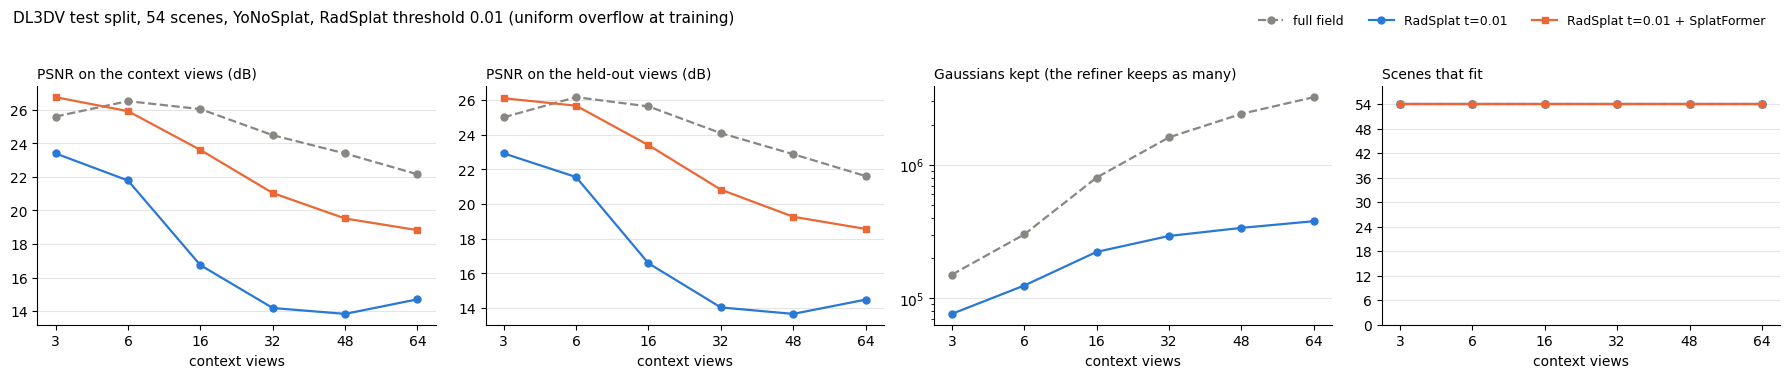

In [ ]:
def plot_threshold_eval(summary: List[dict], generator_name: str, title: str):
    """
    The three methods against the context view count: PSNR on both halves
    of the scene, the primitives kept, and the scenes that fit.
    """
    cells = {(r["context_views"], r["method"]): r for r in summary if r["generator"] == generator_name}
    views = [v for v in EVAL_CONTEXT_VIEWS if any((v, m) in cells for m in METHODS)]
    positions = list(range(len(views)))
    styles = {
        METHOD_FULL: dict(color=REFERENCE_COLOR, linestyle="--", marker="o"),
        METHOD_RADSPLAT: dict(color=SERIES_COLORS[0], marker="o"),
        METHOD_REFINED: dict(color=SERIES_COLORS[1], marker="s"),
    }
    panels = [
        ("self_psnr", "PSNR on the context views (dB)"),
        ("nvs_psnr", "PSNR on the held-out views (dB)"),
        ("num_gaussians", "Gaussians kept (the refiner keeps as many)"),
        ("num_scenes", "Scenes that fit"),
    ]
    figure, axes = plt.subplots(1, 4, figsize=(18, 3.8))
    for axis, (key, label) in zip(axes, panels):
        for method in METHODS:
            if key == "num_gaussians" and method == METHOD_REFINED:
                continue
            xs = [p for p, v in zip(positions, views) if (v, method) in cells]
            ys = [cells[(v, method)][key] for v in views if (v, method) in cells]
            if not xs:
                continue
            axis.plot(xs, ys, label=method, linewidth=1.6, markersize=5, **styles[method])
        axis.set_xticks(positions)
        axis.set_xticklabels([str(v) for v in views])
        axis.set_xlabel("context views")
        axis.set_title(label, fontsize=10, loc="left")
        axis.grid(axis="y", color="#e5e5e5", linewidth=0.8)
        for side in ("top", "right"):
            axis.spines[side].set_visible(False)
        if key == "num_gaussians":
            axis.set_yscale("log")
        if key == "num_scenes":
            axis.set_ylim(0, len(test_scenes) * 1.08)
            axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(handles, labels, frameon=False, fontsize=9, ncol=len(labels), loc="upper right", bbox_to_anchor=(0.99, 1.0))
    figure.suptitle(title, x=0.01, ha="left", fontsize=11)
    figure.tight_layout(rect=(0, 0, 1, 0.95))
    return figure


for generator_name in EVAL_GENERATORS:
    figure = plot_threshold_eval(
        summary, generator_name,
        f"DL3DV test split, {len(test_scenes)} scenes, {generator_name}, RadSplat threshold {SCORE_THRESHOLD:g} "
        f"({OVERFLOW_SELECTION} overflow at training)",
    )
    path = output_dir / f"threshold_eval_{generator_name.lower()}.png"
    figure.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Wrote {path}")
    plt.show()
